# Import utils

In [ ]:
from utils.classification_utils import ClassifierPreprocessor
from utils.dataset_utils import SegmentDatasetAllTimestamps

# Create my own classifier class

In [ ]:
classifier_preprocessor = ClassifierPreprocessor(sensors_path="../../../../data/ml/features.csv", annotation_json="../../../../data/ml/machine-and-movement.json")

# Read and Preprocess for training

In [ ]:
sensors_df, annotation_dict = classifier_preprocessor.read_data()
sensors_df = classifier_preprocessor.feature_selection()
sensors_df = classifier_preprocessor.assign_labels()
sensors_df = classifier_preprocessor.normalize_and_encode_labels()

# Create the Dataloader

In [ ]:
from torch.utils.data import DataLoader
batch_size = 64
train_df, val_df, test_df, experiment_ids = classifier_preprocessor.split_experiments()
train_dataset, val_dataset, test_dataset = classifier_preprocessor.create_datasets(
    train_df, val_df, test_df, SegmentDatasetAllTimestamps
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Total experiments: 100
Train experiments: 70
Val experiments: 20
Test experiments: 10


# Create the model and train

In [ ]:
feature_cols = classifier_preprocessor.get_feature_cols()
input_size = len(feature_cols)
hidden_size = 64
num_layers = 2
num_classes = len(train_dataset.unique_labels)

In [6]:
import torch
from utils.model import LSTMClassifier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(input_size, hidden_size, num_layers, num_classes).to(device)

In [7]:
model.train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    learning_rate=1e-5,
    patience=3,
    device=device,
    model_path="../../../../models/classifier"
)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100:   0%|          | 0/1622 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/1622 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/1622 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/1622 [00:00<?, ?it/s]

...

Epoch 97/100:   0%|          | 0/1622 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/1622 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/1622 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/1622 [00:00<?, ?it/s]


Training complete. Best model loaded.


# Load and Evaluate the Model

In [8]:
import joblib

# define model architecture (must match training!)
model = LSTMClassifier(input_size, hidden_size, num_layers, num_classes).to(device)

# load state_dict via joblib
state_dict = joblib.load("../../../../models/classifier/Activity_Detector.joblib")
model.load_state_dict(state_dict)
model.eval()

LSTMClassifier(
  (lstm): LSTM(17, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

# Vizualize the Prediction

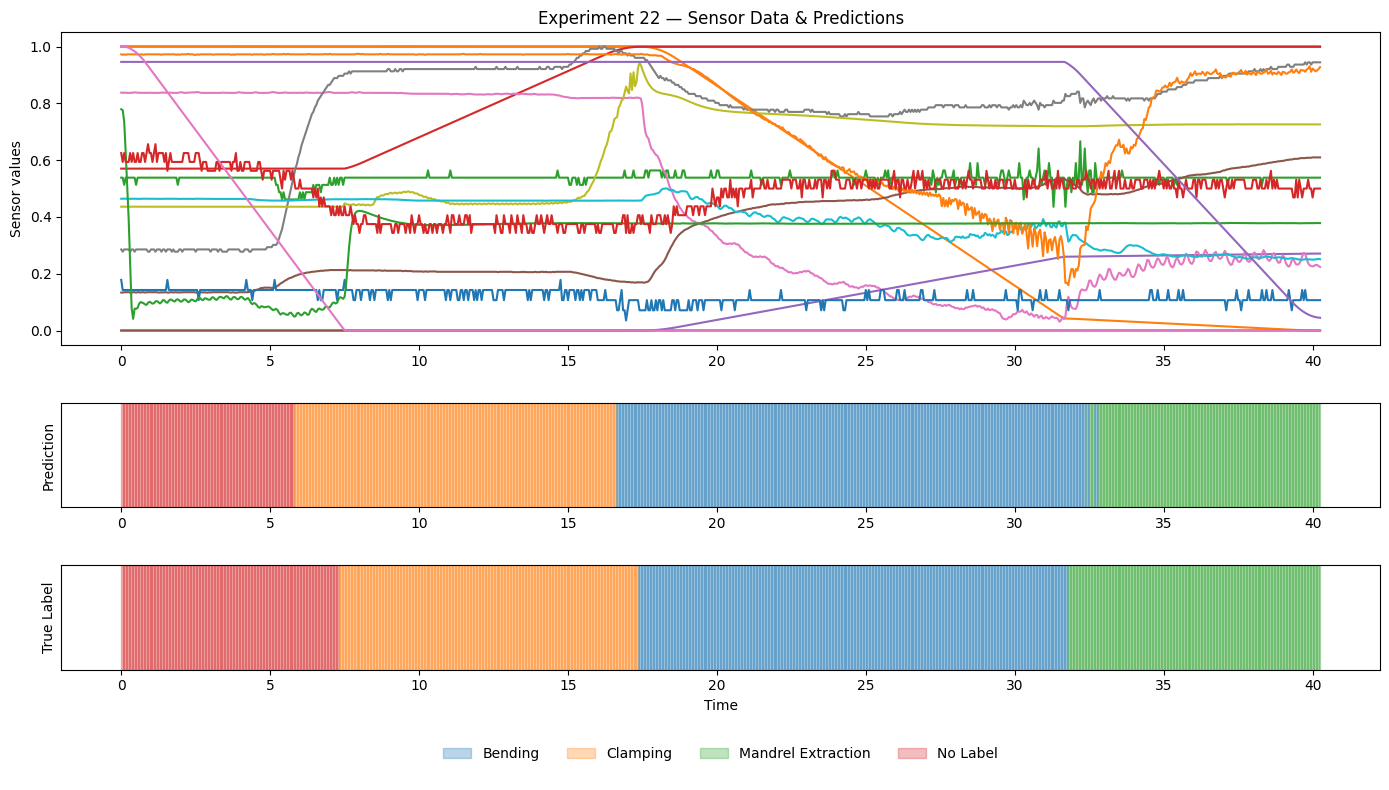

In [9]:
from utils.plot_utils import plot_predictions_vs_true_annot
plot_predictions_vs_true_annot(model, test_dataset, sensors_df, feature_cols, experiment_ids)